In [1]:
# Program 13: Data Transformation & Standardization
# Step 1: Load Dataset
import pandas as pd
import numpy as np

# Step 1: Load Dataset
df = pd.read_csv('employee.csv')

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 Rows:
   Company   Age  Salary     Place Country  Gender Department
0  Infosys  30.0     NaN    Mumbai   India       0         HR
1      TCS  35.0  2300.0  Calcutta   India       0         IT
2  Infosys  40.0  3000.0     Delhi   India       0    Finance
3      TCS  23.0  4000.0    Mumbai   India       0         IT
4  Infosys   NaN  5000.0  Calcutta   India       0         HR

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Company     32 non-null     object 
 1   Age         28 non-null     float64
 2   Salary      27 non-null     float64
 3   Place       32 non-null     object 
 4   Country     32 non-null     object 
 5   Gender      32 non-null     int64  
 6   Department  32 non-null     object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.9+ KB
None


In [2]:
# Step 2: Handle Missing Values

# Convert blank values to NaN
df.replace("", np.nan, inplace=True)

# Fill missing Age with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Salary with median
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

# Fill missing Place with mode
df['Place'] = df['Place'].fillna(df['Place'].mode()[0])

In [3]:
# Step 3: Encode Categorical Data

# Label Encoding for Company, Place, Country
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder() 
df['Department'] = le.fit_transform(df['Department'])

# Gender is already numeric (0/1), so no need

print("\nAfter Encoding:")
print(df.head())

#One-Hot Encoding 
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)


After Encoding:
   Company    Age  Salary     Place Country  Gender  Department
0  Infosys  30.00  4824.0    Mumbai   India       0           1
1      TCS  35.00  2300.0  Calcutta   India       0           2
2  Infosys  40.00  3000.0     Delhi   India       0           0
3      TCS  23.00  4000.0    Mumbai   India       0           2
4  Infosys  32.25  5000.0  Calcutta   India       0           1


In [4]:
# Step 4: Scale or Normalize Numerical Columns 
# Standard Scaling 
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
df[['Age', 'Salary']] = scaler.fit_transform(df[['Age', 'Salary']])

In [5]:
#Min-Max Scaling 
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler() 
df[['Age', 'Salary']] = scaler.fit_transform(df[['Age', 'Salary']])


In [6]:
# Step 5: Subset Features for Analysis 
# Select only relevant columns 

df_subset = df[['Age', 'Salary', 'Department', 'Gender_1']]
print(df_subset.head())

        Age    Salary  Department  Gender_1
0  0.375000  0.425060           1     False
1  0.531250  0.137817           2     False
2  0.687500  0.217480           0     False
3  0.156250  0.331285           2     False
4  0.445312  0.445089           1     False


In [7]:
print("\nFinal Cleaned Dataset:")
print(df.head())


Final Cleaned Dataset:
   Company       Age    Salary     Place Country  Department  Gender_1
0  Infosys  0.375000  0.425060    Mumbai   India           1     False
1      TCS  0.531250  0.137817  Calcutta   India           2     False
2  Infosys  0.687500  0.217480     Delhi   India           0     False
3      TCS  0.156250  0.331285    Mumbai   India           2     False
4  Infosys  0.445312  0.445089  Calcutta   India           1     False


In [8]:
# Step 6: Split Dataset into Analytical Subsets

dept_groups = df.groupby('Department')
for dept, group in dept_groups:
    print(f"\nDepartment: {dept}")
    print(group.head())


Department: 0
    Company      Age    Salary    Place Country  Department  Gender_1
2   Infosys  0.68750  0.217480    Delhi   India           0     False
6   Infosys  0.15625  0.672698   Mumbai   India           0      True
8       CTS  0.84375  0.900307    Delhi   India           0     False
11      CTS  0.84375  0.425060  Chennai   India           0     False
14      TCS  0.15625  0.217480    Delhi   India           0     False

Department: 1
    Company       Age    Salary       Place Country  Department  Gender_1
0   Infosys  0.375000  0.425060      Mumbai   India           1     False
4   Infosys  0.445312  0.445089    Calcutta   India           1     False
9       CTS  0.156250  0.425060      Mumbai   India           1     False
12      CTS  0.000000  0.016502      Mumbai   India           1     False
15  Infosys  0.156250  0.220895  Podicherry   India           1     False

Department: 2
   Company       Age    Salary     Place Country  Department  Gender_1
1      TCS  0.531250

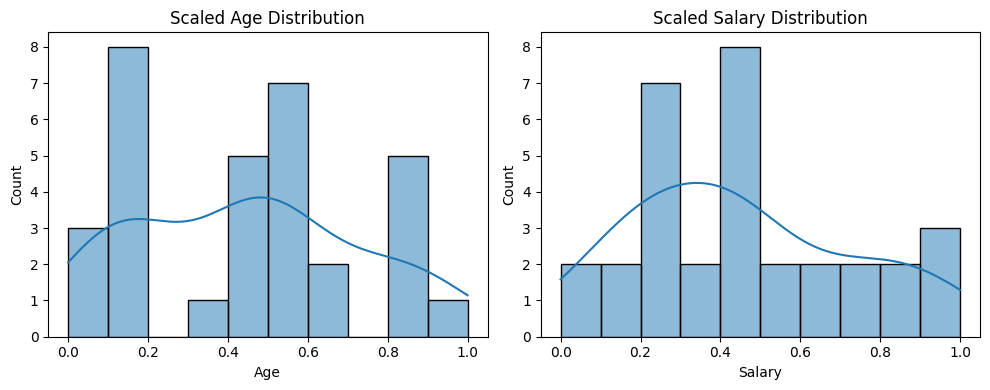

In [9]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Age'], kde=True, bins=10)
plt.title('Scaled Age Distribution')

plt.subplot(1,2,2)
sns.histplot(df['Salary'], kde=True, bins=10)
plt.title('Scaled Salary Distribution')

plt.tight_layout()
plt.show()

In [10]:
print(df.head())
df.to_csv("emp1.csv")
print("file save")

   Company       Age    Salary     Place Country  Department  Gender_1
0  Infosys  0.375000  0.425060    Mumbai   India           1     False
1      TCS  0.531250  0.137817  Calcutta   India           2     False
2  Infosys  0.687500  0.217480     Delhi   India           0     False
3      TCS  0.156250  0.331285    Mumbai   India           2     False
4  Infosys  0.445312  0.445089  Calcutta   India           1     False
file save
